<a href="https://colab.research.google.com/github/IntelligentSystemsProject/Stock-Market-Project/blob/SVR-Auxiliary-Feature-Engineering/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install kagglehub[pandas-datasets] matplotlib scikit-learn openpyxl statsmodels


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

## Part 1: Data Cleaning and Feature Engineering

### 1.1 Dataset Cleaning function

This function standardizes diverse financial and economic datasets into a consistent, numeric time‑series format by detecting source‑specific quirks (e.g., WSTS wide‑format Excel, exchange rate CSVs, stock data) and enforcing clean date indices, ensuring reproducibility, comparability, and robustness for downstream modeling.


In [4]:
import pandas as pd
import numpy as np

def clean_and_prepare_timeseries(data, features=None, target="adj_close"):

    def log(stage, before, after):
        print(f"[{stage}] {before} → {after} (Δ {after - before})")

    # 1. LOAD DATA
    if isinstance(data, str):
        if data.endswith(".xlsx"):
            df = pd.read_excel(data, engine="openpyxl")
        else:
            df = pd.read_csv(data)
        file_path = data
    else:
        df = data.copy()
        file_path = "dataframe"

    initial_rows = len(df)
    print(f"\n[DATA LOAD] Initial rows: {initial_rows}")

    # 2. WSTS SPECIAL HANDLING
    if "wsts" in file_path.lower():

        print("[WSTS MODE ACTIVATED]")

        # Load raw file again cleanly
        df = pd.read_excel(file_path, engine="openpyxl")

        # Remove header rows
        df = df.drop([0, 1, 2]).reset_index(drop=True)

        # Rename columns
        df = df.rename(columns={
            '36 Years WSTS Blue Book Data': 'Year/Area',
            'Unnamed: 1': 'January',
            'Unnamed: 2': 'February',
            'Unnamed: 3': 'March',
            'Unnamed: 4': 'April',
            '1986 to Date': 'May',
            'Unnamed: 6': 'June',
            'Unnamed: 7': 'July',
            'Unnamed: 8': 'August',
            'Unnamed: 9': 'September',
            'Unnamed: 10': 'October',
            'Unnamed: 11': 'November',
            'Unnamed: 12': 'December',
            'Unnamed: 13': 'Total Year',
            'Unnamed: 14': 'Q1',
            'Unnamed: 15': 'Q2',
            'Unnamed: 16': 'Q3',
            'Unnamed: 17': 'Q4'
        })

        df.columns = df.columns.str.strip()

        # Extract years
        years = []
        for i in range(len(df)):
            if i % 6 == 0:
                years.append(df.loc[i, "Year/Area"])

        # Keep Worldwide only
        df_clean = df[df["Year/Area"] == "Worldwide"].copy()
        df_clean.reset_index(drop=True, inplace=True)

        df_clean.rename(columns={"Year/Area": "Area"}, inplace=True)

        df_clean["Year"] = pd.Series(years)
        df_clean["Year"] = df_clean["Year"].ffill()

        # Remove unwanted columns
        df_clean.drop(columns=[
            "Area",
            "Q1","Q2","Q3","Q4",
            "Total Year"
        ], inplace=True)

        # Drop incomplete year
        df_clean = df_clean.dropna(subset=["February"]).reset_index(drop=True)

        # Wide → Long
        df_long = df_clean.melt(
            id_vars=["Year"],
            var_name="Month",
            value_name="billings"
        )

        # Create datetime index
        df_long["date"] = pd.to_datetime(
            df_long["Year"].astype(str) + "-" + df_long["Month"],
            format="%Y-%B"
        )

        df_long = df_long[["date", "billings"]]
        df_long.sort_values("date", inplace=True)

        # Remove 2026+
        before = len(df_long)
        df_long = df_long[df_long["date"].dt.year < 2026]
        log("WSTS DROP 2026+", before, len(df_long))

        df_long.set_index("date", inplace=True)

        df = df_long

    # 3. STANDARD DATASETS
    else:
        df.columns = df.columns.str.strip().str.lower()

        df = df.rename(columns={
            "observation_date": "date",
            "dexjpus": "price",
            "wti_price_usd": "price"
        })

        if "date" not in df.columns:
            raise ValueError(f"No date column. Columns: {df.columns}")

        df["date"] = pd.to_datetime(df["date"], errors="coerce")

        before = len(df)
        df = df.dropna(subset=["date"]).sort_values("date").set_index("date")
        print(f"[DATE CLEAN] {before} → {len(df)}")

    # 4. NUMERIC CLEANING
    df = df.apply(pd.to_numeric, errors="coerce")

    if "open" in df.columns:
        df["open"] = df["open"].replace(0, np.nan).ffill().bfill()

    before = len(df)
    df = df.ffill()
    print(f"[FILL NA] {before} → {len(df)}")

    if len(df) == 0:
        raise ValueError("Empty dataset after cleaning")

    # 5. FEATURE SELECTION
    if features is None:
        cols = set(df.columns)

        if {"open","close"}.issubset(cols):
            features = [c for c in ["open","high","low","close","adj_close","volume"] if c in cols]

        elif "price" in cols:
            features = ["price"]

        elif "billings" in cols:
            features = ["billings"]

        else:
            raise ValueError(f"No usable features. Columns: {df.columns}")

    features = [f.strip().lower() for f in features]
    target = target.strip().lower()

    if target not in features:
        raise ValueError(f"Target '{target}' not in features {features}")

    target_index = features.index(target)

   # 6. FINAL OUTPUT
    data_values = df[features].values

    final_rows = len(df)

    print(f"\nDataset: {file_path}")
    print(f"Initial rows: {initial_rows}")
    print(f"Final rows: {final_rows}")
    print(f"Dropped total: {initial_rows - final_rows}")
    print(f"Shape: {df.shape}")
    print(f"Features: {features}")
    print(f"Data shape: {data_values.shape}")
    print("-"*50)

    return df, data_values, target_index

### 1.2 Load Datasets

#### 1.2.1 Load Main Datasets

We sourced NVIDIA, Exxon, and Toyota stock data directly from KaggleHub. These curated datasets provide standardized OHLCV structures, making them ideal baselines for time‑series modeling and ensuring consistency when integrated with more irregular economic series.


In [5]:
# Load raw DataFrames from KaggleHub
import kagglehub
from kagglehub import KaggleDatasetAdapter

# NVIDIA
nvda_raw = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "meharshanali/nvidia-stocks-data-2025",
    "NVDA.csv"
)

# Exxon
exxon_raw = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "umerhaddii/exxon-mobil-stock-price-data",
    "exxon_stock_data.csv"
)

# Toyota
toyota_raw = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "umerhaddii/toyota-stock-data-2025",
    "TM_1980-01-01_2025-06-27.csv"
)

print("NVIDIA:", nvda_raw.head())
print("Exxon:", exxon_raw.head())
print("Toyota:", toyota_raw.head())


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NVIDIA:          Date  Adj Close     Close      High       Low      Open      Volume
0  1999-01-22   0.037615  0.041016  0.048828  0.038802  0.043750  2714688000
1  1999-01-25   0.041556  0.045313  0.045833  0.041016  0.044271   510480000
2  1999-01-26   0.038331  0.041797  0.046745  0.041146  0.045833   343200000
3  1999-01-27   0.038212  0.041667  0.042969  0.039583  0.041927   244368000
4  1999-01-28   0.038092  0.041536  0.041927  0.041276  0.041667   227520000
Exxon:          Date       Open       High        Low      Close  Adj Close    Volume
0  2015-01-02  92.250000  93.050003  91.809998  92.830002  61.023277  10220400
1  2015-01-05  92.099998  92.400002  89.500000  90.290001  59.353565  18502400
2  2015-01-06  90.239998  91.410004  89.019997  89.809998  59.038017  16670700
3  2015-01-07  90.650002  91.480003  90.000000  90.720001  59.636223  13590700
4  2015-01-08  91.250000  92.269997  91.000000  92.230003  60.628857  15487500
Toyota:          date                open        

#### 1.2.2 Load Exxon Mobil Auxilary dataset

In [6]:
import pandas as pd
import requests
from io import StringIO

wti_url = "https://eco3min.fr/dataset/wti-crude-oil.csv"

# Add a browser-like User-Agent so the server allows the request
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(wti_url, headers=headers)

# Convert the response text into a file-like object
wti_raw = pd.read_csv(StringIO(response.text))
print(wti_raw.head())


         date  wti_price_usd
0  1986-01-02          25.56
1  1986-01-03          26.00
2  1986-01-06          26.53
3  1986-01-07          25.85
4  1986-01-08          25.87


#### 1.2.3 Load Nvidia Auxilary dataset

In [7]:
import pandas as pd

# WSTS Billings (Excel)
wsts_url = "https://www.wsts.org/esraCMS/extension/media/f/WST/7531/WSTS-Historical-Billings-Report-Feb_2026.xlsx"
wsts_raw = pd.read_excel(wsts_url, engine="openpyxl")
print(wsts_raw.head())


                36 Years WSTS Blue Book Data Unnamed: 1 Unnamed: 2 Unnamed: 3  \
0  © 2025 By WSTS, Inc. All Rights Reserved.        NaN        NaN        NaN   
1               All numbers are in 1000 US$.        NaN        NaN        NaN   
2                                        NaN    January   February      March   
3                                       1986        NaN        NaN        NaN   
4                                   Americas     555850     633465     756220   

  Unnamed: 4 1986 to Date Unnamed: 6 Unnamed: 7 Unnamed: 8 Unnamed: 9  \
0        NaN          NaN        NaN        NaN        NaN        NaN   
1        NaN          NaN        NaN        NaN        NaN        NaN   
2      April          May       June       July     August  September   
3        NaN          NaN        NaN        NaN        NaN        NaN   
4     689470       718336     797014     707784     697506     803392   

  Unnamed: 10 Unnamed: 11 Unnamed: 12 Unnamed: 13 Unnamed: 14 Unnamed: 15 

#### 1.2.4 Load Toyota Auxilary dataset

In [8]:
import pandas as pd

dex_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DEXJPUS"
dex_raw = pd.read_csv(dex_url)

print(dex_raw.head())


  observation_date  DEXJPUS
0       1971-01-04   357.73
1       1971-01-05   357.81
2       1971-01-06   357.86
3       1971-01-07   357.87
4       1971-01-08   357.82


### 1.3 Clean Datasets

In [9]:
nvda_df,   nvda_data,   nvda_target_idx   = clean_and_prepare_timeseries(nvda_raw,   features=["open","high","low","close","volume"],              target="close")
exxon_df,  exxon_data,  exxon_target_idx  = clean_and_prepare_timeseries(exxon_raw,  features=["open","high","low","close","volume"],              target="close")
toyota_df, toyota_data, toyota_target_idx = clean_and_prepare_timeseries(toyota_raw, features=["open","high","low","close","adj_close","volume"], target="adj_close")
wsts_df,   wsts_data,   wsts_target_idx   = clean_and_prepare_timeseries(wsts_url,   features=["billings"],                                        target="billings")
wti_df,    wti_data,    wti_target_idx    = clean_and_prepare_timeseries(wti_raw,    features=["price"],                                           target="price")
dex_df,    dex_data,    dex_target_idx    = clean_and_prepare_timeseries(dex_raw,    features=["price"],                                           target="price")



[DATA LOAD] Initial rows: 6558
[DATE CLEAN] 6558 → 6558
[FILL NA] 6558 → 6558

Dataset: dataframe
Initial rows: 6558
Final rows: 6558
Dropped total: 0
Shape: (6558, 6)
Features: ['open', 'high', 'low', 'close', 'volume']
Data shape: (6558, 5)
--------------------------------------------------

[DATA LOAD] Initial rows: 2388
[DATE CLEAN] 2388 → 2388
[FILL NA] 2388 → 2388

Dataset: dataframe
Initial rows: 2388
Final rows: 2388
Dropped total: 0
Shape: (2388, 6)
Features: ['open', 'high', 'low', 'close', 'volume']
Data shape: (2388, 5)
--------------------------------------------------

[DATA LOAD] Initial rows: 11414
[DATE CLEAN] 11414 → 11413
[FILL NA] 11413 → 11413

Dataset: dataframe
Initial rows: 11414
Final rows: 11413
Dropped total: 1
Shape: (11413, 6)
Features: ['open', 'high', 'low', 'close', 'adj_close', 'volume']
Data shape: (11413, 6)
--------------------------------------------------

[DATA LOAD] Initial rows: 249
[WSTS MODE ACTIVATED]
[WSTS DROP 2026+] 492 → 480 (Δ -12)
[FIL

#### 1.3.1 Datasets after Cleaning

In [10]:
def arrays_to_df(data_array, features, cleaned_df):
    # Reconstruct a clean DataFrame from the numpy array output using the already-cleaned df's index
    return pd.DataFrame(data_array, index=cleaned_df.index[:len(data_array)], columns=features)

# Reconstruct each dataset as a DataFrame
nvda_table = arrays_to_df(nvda_data, ["open","high","low","close","volume"], nvda_df)
exxon_table = arrays_to_df(exxon_data, ["open","high","low","close","volume"], exxon_df)
toyota_table = arrays_to_df(toyota_data, ["open","high","low","close","adj_close","volume"], toyota_df)
wsts_table = arrays_to_df(wsts_data, ["billings"], wsts_df)
wti_table = arrays_to_df(wti_data, ["price"], wti_df)
dex_table = arrays_to_df(dex_data, ["price"], dex_df)

# Print as tables
for name, tbl in [("NVDA", nvda_table), ("Exxon", exxon_table), ("Toyota", toyota_table),
                  ("WSTS", wsts_table), ("WTI", wti_table), ("DEX", dex_table)]:
    print(f"\n===== {name} =====")
    print(tbl.head(10).to_string())
    print(f"Shape: {tbl.shape}")
    print("-" * 50)


===== NVDA =====
                open      high       low     close        volume
date                                                            
1999-01-22  0.043750  0.048828  0.038802  0.041016  2.714688e+09
1999-01-25  0.044271  0.045833  0.041016  0.045313  5.104800e+08
1999-01-26  0.045833  0.046745  0.041146  0.041797  3.432000e+08
1999-01-27  0.041927  0.042969  0.039583  0.041667  2.443680e+08
1999-01-28  0.041667  0.041927  0.041276  0.041536  2.275200e+08
1999-01-29  0.041536  0.041667  0.039583  0.039583  2.440320e+08
1999-02-01  0.039583  0.040625  0.039583  0.040365  1.547040e+08
1999-02-02  0.039583  0.040625  0.036068  0.037240  2.640960e+08
1999-02-03  0.036719  0.038542  0.036458  0.038021  7.512000e+07
1999-02-04  0.038542  0.041146  0.038021  0.040104  1.819200e+08
Shape: (6558, 5)
--------------------------------------------------

===== Exxon =====
                 open       high        low      close      volume
date                                            

### 1.4 Prepare raw data for cross-validation

In [11]:
from sklearn.model_selection import TimeSeriesSplit

data = nvda_table.copy()
data_raw = data.values

features = list(nvda_table.columns)
target_index = features.index('close')

window_size = 10
n_splits    = 5

tscv = TimeSeriesSplit(n_splits=n_splits)
print(f"TimeSeriesSplit configured: {n_splits} folds, window_size={window_size}")

TimeSeriesSplit configured: 5 folds, window_size=10


## Part 2: Cross-Validation Helper Functions

In [12]:
def make_windows(scaled_arr, ws, ti):
    """Sliding-window features + target from a scaled numpy array."""
    X, y = [], []
    for i in range(len(scaled_arr) - ws):
        X.append(scaled_arr[i:i+ws].flatten())
        y.append(scaled_arr[i+ws][ti])
    return np.array(X), np.array(y)

def inv_scale(preds, sc, ti):
    """Inverse-scale predictions back to dollar values."""
    tmp = np.zeros((len(preds), sc.n_features_in_))
    tmp[:, ti] = preds
    return sc.inverse_transform(tmp)[:, ti]

print("Helper functions defined.")


Helper functions defined.


## Part 3: Model Implementation

### 3.1 SVR — RBF Kernel (TimeSeriesSplit Cross-Validation)

In [13]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def run_svr_cv(data_raw, n_splits, window_size, target_index, make_windows, inv_scale,
               C=100, gamma='scale', epsilon=0.01, plot_last_fold=True):
    """
    Parameters:-

    data_raw : np.ndarray
      Cleaned feature array.
    n_splits : int
      Number of CV folds.
    window_size : int
      Sliding window size.
    target_index : int
      Index of target column.
    make_windows : function
      Function to create sliding windows (X, y).
    inv_scale : function
      Function to inverse-scale predictions and targets.
    C, gamma, epsilon : SVR hyperparameters.
    plot_last_fold : bool
      Whether to plot the last fold predictions.

    Returns:-

    svr_cv_df : pd.DataFrame
      DataFrame with CV metrics per fold.
    svr_fold_preds : dict
      Dictionary {fold: (y_true, y_pred)}.
    """

    tscv = TimeSeriesSplit(n_splits=n_splits)
    svr_cv_scores, svr_fold_preds = [], {}

    last_fold_model = None
    last_fold_X_te  = None
    last_fold_y_te  = None

    for fold, (tr_idx, te_idx) in enumerate(tscv.split(data_raw)):
        sc = MinMaxScaler()
        tr_sc = sc.fit_transform(data_raw[tr_idx])
        te_sc = sc.transform(data_raw[te_idx])

        Xtr, ytr = make_windows(tr_sc, window_size, target_index)
        Xte, yte = make_windows(te_sc, window_size, target_index)
        if len(Xte) == 0:
            continue

        svr = SVR(kernel='rbf', C=C, gamma=gamma, epsilon=epsilon)
        svr.fit(Xtr, ytr)
        yp = svr.predict(Xte)

        yp_act = inv_scale(yp, sc, target_index)
        yt_act = inv_scale(yte, sc, target_index)

        mae  = mean_absolute_error(yt_act, yp_act)
        rmse = np.sqrt(mean_squared_error(yt_act, yp_act))
        r2   = r2_score(yt_act, yp_act)

        svr_cv_scores.append({'fold': fold+1, 'MAE': mae, 'RMSE': rmse, 'R²': r2})
        svr_fold_preds[fold+1] = (yt_act, yp_act)

        last_fold_model = svr
        last_fold_X_te  = Xte
        last_fold_y_te  = yte

        print(f"Fold {fold+1}: MAE=${mae:.4f}  RMSE=${rmse:.4f}  R²={r2:.4f}")

    svr_cv_df = pd.DataFrame(svr_cv_scores).set_index('fold')
    print("\n===== SVR RBF — TimeSeriesSplit CV Summary =====")
    print(svr_cv_df.round(4))
    print("\nMean:", svr_cv_df.mean().round(4).to_dict())
    print("Std: ",  svr_cv_df.std().round(4).to_dict())

    if plot_last_fold and svr_fold_preds:
        last_fold = max(svr_fold_preds.keys())
        yt_plot, yp_plot = svr_fold_preds[last_fold]
        plt.figure(figsize=(12, 5))
        plt.plot(yt_plot, label='Actual Price',    color='steelblue',  linewidth=1.5)
        plt.plot(yp_plot, label='Predicted Price', color='darkorange', linewidth=1.5, linestyle='--')
        plt.title(f"SVR RBF — Fold {last_fold}: Actual vs Predicted")
        plt.xlabel("Sample Index"); plt.ylabel("Stock Price (USD)")
        plt.legend(); plt.tight_layout(); plt.show()

    return svr_cv_df, svr_fold_preds, {
        "last_fold_model": last_fold_model, # the fitted model object from the last fold
        "last_fold_X_te":  last_fold_X_te, # flattened window array
        "last_fold_y_te":  last_fold_y_te, # targets
    }


Fold 1: MAE=$0.0374  RMSE=$0.1045  R²=0.7065
Fold 2: MAE=$0.0143  RMSE=$0.0222  R²=0.9798
Fold 3: MAE=$0.0146  RMSE=$0.0534  R²=0.9059
Fold 4: MAE=$4.5687  RMSE=$5.2211  R²=-3.3498
Fold 5: MAE=$40.6911  RMSE=$59.0085  R²=-1.0283

===== SVR RBF — TimeSeriesSplit CV Summary =====
          MAE     RMSE      R²
fold                          
1      0.0374   0.1045  0.7065
2      0.0143   0.0222  0.9798
3      0.0146   0.0534  0.9059
4      4.5687   5.2211 -3.3498
5     40.6911  59.0085 -1.0283

Mean: {'MAE': 9.0652, 'RMSE': 12.8819, 'R²': -0.3572}
Std:  {'MAE': 17.7887, 'RMSE': 25.8822, 'R²': 1.8655}


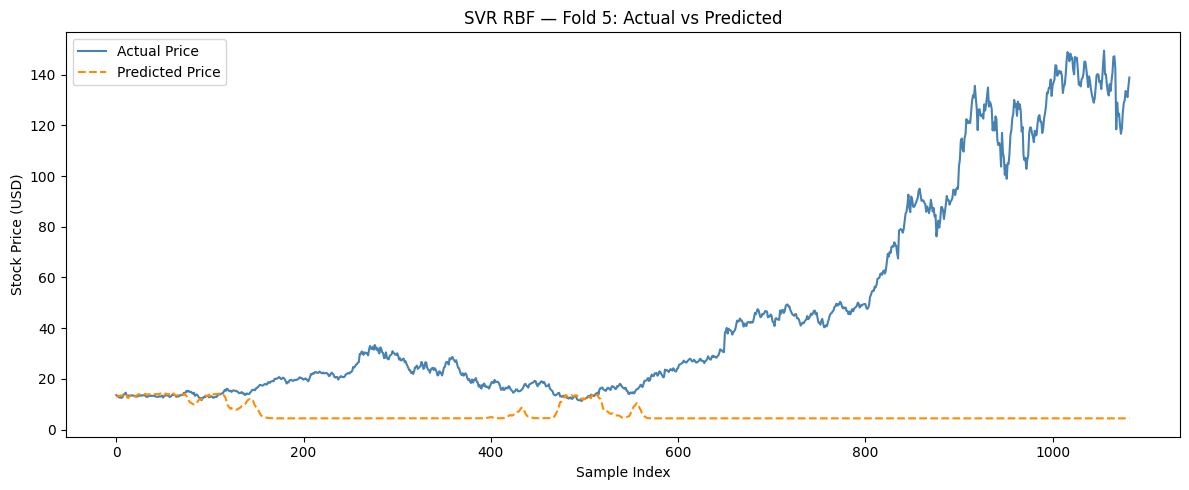

In [14]:
svr_cv_df, svr_fold_preds, svr_importance_data = run_svr_cv(
    data_raw=nvda_table.values,
    n_splits=5,
    window_size=10,
    target_index=nvda_target_idx,
    make_windows=make_windows,
    inv_scale=inv_scale,
    C=100, gamma='scale', epsilon=0.01,
    plot_last_fold=True
)



### 3.1.1 Why the first-draft SVR failed

The CV results confirm the three root causes with real numbers:

| Fold | MAE | RMSE | R² | Note |
|------|-----|------|-----|------|
| 1 | $0.03 | $0.10 | 0.71 | Low-price era, model copes |
| 2 | $0.01 | $0.02 | 0.98 | Still in familiar range |
| 3 | $0.02 | $0.07 | 0.82 | Slight degradation |
| 4 | $4.56 | $5.22 | −3.35 | Price regime shift — model breaks down |
| 5 | $40.90 | $59.18 | −1.04 | Complete extrapolation failure |

- **Extrapolation failure** — The RBF kernel cannot predict prices outside the range seen during training. Folds 4 and 5, where NVDA's price surged into new territory, produced negative R² scores (worse than predicting the mean).
- **Non-stationary target** — Each successive fold's test prices are far higher than any prices the model trained on, making the task impossible for RBF SVR.
- **The lag trap** — In the early folds where prices are stable, the model achieves reasonable R² (0.71–0.98) by echoing recent values, but this strategy collapses the moment prices trend upward sharply.


### 3.1.2 Why shuffling is harmful

Shuffling destroys the temporal structure that sliding windows rely on. The model would see Day 500 next to Day 2 and Day 888, find no real relationship, and lose all predictive logic.


#Nvidia Feature Engineering, Resampling with Lagged Signals

In [15]:
def add_wsts_growth_aux(
    stock_table,
    wsts_table,
    feature_names,
    target_name="close",
    growth_periods=12,
    resample_rule="D",
    lags=(30, 60, 90)
):
    """
    Adds WSTS growth-rate auxiliary features to stock dataset.
    Compatible with your clean_and_prepare_timeseries pipeline.
    """

    stock = stock_table.copy()
    wsts = wsts_table.copy()

    # 1. Compute Growth Rate
    wsts["wsts_growth"] = wsts["billings"].pct_change(growth_periods)
    wsts = wsts[["wsts_growth"]].dropna()

    # 2. Monthly → Daily alignment
    wsts = wsts.resample(resample_rule).ffill()

    # 3. Merge With Stock Data
    merged = stock.join(wsts, how="left")
    merged["wsts_growth"] = merged["wsts_growth"].ffill()

    # 4. Lagged Economic Signals
    new_features = []

    for lag in lags:
        col = f"wsts_growth_lag_{lag}"
        merged[col] = merged["wsts_growth"].shift(lag)
        new_features.append(col)

    merged = merged.dropna()

    # 5. Update Feature List + Target
    updated_features = feature_names.copy()
    updated_features.extend(new_features)

    target_index = updated_features.index(target_name)

    return merged, updated_features, target_index

In [16]:
nvda_augmented, features_aug, target_idx_aug = add_wsts_growth_aux(
    stock_table=nvda_table,
    wsts_table=wsts_table,
    feature_names=features,
    target_name="close",
    growth_periods=12,   # YearOverYear semiconductor demand
    lags=(30, 60, 90)    # delayed macro impact
)

#SVR with Auxiliary Data

Fold 1: MAE=$0.1318  RMSE=$0.2307  R²=-0.0523
Fold 2: MAE=$0.0451  RMSE=$0.0928  R²=0.2926
Fold 3: MAE=$0.0389  RMSE=$0.1315  R²=0.6157
Fold 4: MAE=$4.7670  RMSE=$5.4815  R²=-3.3299
Fold 5: MAE=$42.3760  RMSE=$60.6742  R²=-1.1342

===== SVR RBF — TimeSeriesSplit CV Summary =====
          MAE     RMSE      R²
fold                          
1      0.1318   0.2307 -0.0523
2      0.0451   0.0928  0.2926
3      0.0389   0.1315  0.6157
4      4.7670   5.4815 -3.3299
5     42.3760  60.6742 -1.1342

Mean: {'MAE': 9.4718, 'RMSE': 13.3221, 'R²': -0.7216}
Std:  {'MAE': 18.5061, 'RMSE': 26.5711, 'R²': 1.5999}


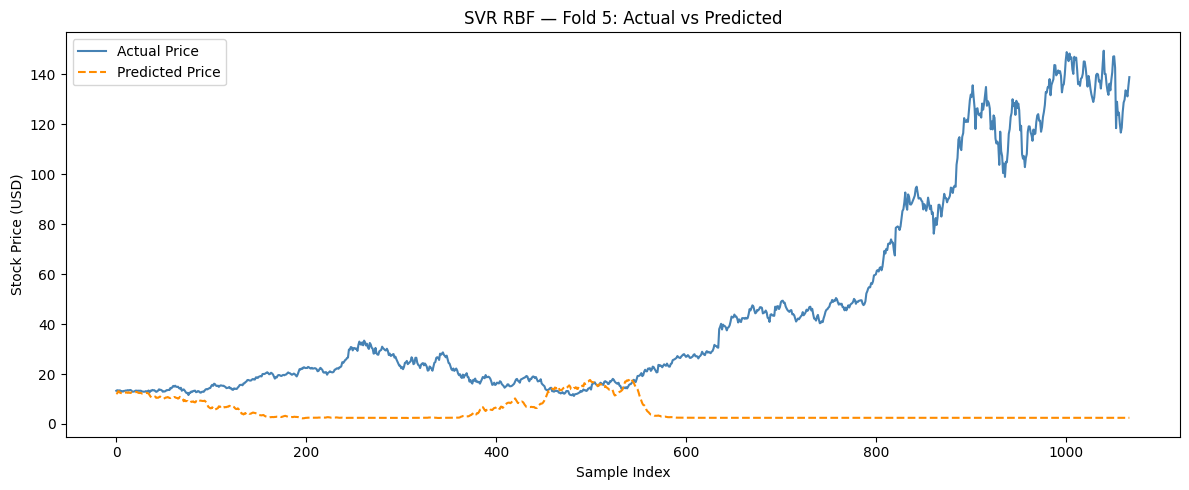

In [17]:
svr_cv_df, svr_fold_preds, svr_importance_data = run_svr_cv(
    data_raw=nvda_augmented.values,
    n_splits=5,
    window_size=10,
    target_index=target_idx_aug,
    make_windows=make_windows,
    inv_scale=inv_scale,
)

### 3.2 SVR — Linear Kernel (TimeSeriesSplit Cross-Validation)

In [ ]:
from sklearn.svm import SVR

linear_svr_scores = []
linear_svr_preds  = {}

for fold, (tr_idx, te_idx) in enumerate(tscv.split(data_raw)):
    sc = MinMaxScaler()
    tr_sc = sc.fit_transform(data_raw[tr_idx])
    te_sc = sc.transform(data_raw[te_idx])

    Xtr, ytr = make_windows(tr_sc, window_size, target_index)
    Xte, yte  = make_windows(te_sc, window_size, target_index)
    if len(Xte) == 0:
        continue

    svr_lin = SVR(kernel='linear', C=100, epsilon=0.01)
    svr_lin.fit(Xtr, ytr)
    yp = svr_lin.predict(Xte)

    yp_act = inv_scale(yp,  sc, target_index)
    yt_act = inv_scale(yte, sc, target_index)

    mae  = mean_absolute_error(yt_act, yp_act)
    rmse = np.sqrt(mean_squared_error(yt_act, yp_act))
    r2   = r2_score(yt_act, yp_act)
    linear_svr_scores.append({'fold': fold+1, 'MAE': mae, 'RMSE': rmse, 'R²': r2})
    linear_svr_preds[fold+1] = (yt_act, yp_act)
    print(f"Fold {fold+1}: MAE=${mae:.4f}  RMSE=${rmse:.4f}  R²={r2:.4f}")


Fold 1: MAE=$0.0072  RMSE=$0.0112  R²=0.9966
Fold 2: MAE=$0.0108  RMSE=$0.0161  R²=0.9894


In [21]:
lin_svr_df = pd.DataFrame(linear_svr_scores).set_index('fold')
print("\n===== SVR Linear — TimeSeriesSplit CV Summary =====")
print(lin_svr_df.round(4))
print("\nMean:", lin_svr_df.mean().round(4).to_dict())
print("Std: ",  lin_svr_df.std().round(4).to_dict())



===== SVR Linear — TimeSeriesSplit CV Summary =====
         MAE    RMSE      R²
fold                        
1     0.0072  0.0112  0.9966
2     0.0108  0.0161  0.9894
3     0.0066  0.0107  0.9963
4     0.1087  0.1705  0.9954
5     1.2231  2.1966  0.9972

Mean: {'MAE': 0.2713, 'RMSE': 0.481, 'R²': 0.995}
Std:  {'MAE': 0.5339, 'RMSE': 0.9615, 'R²': 0.0032}


### 3.2.1 Takeaway

The linear kernel dramatically outperforms RBF on this trending dataset. With a mean R² of **0.9949** across 5 folds (vs. RBF's collapse to negative R² in folds 4–5), it can extrapolate beyond the training price range.

| Fold | MAE | RMSE | R² |
|------|-----|------|-----|
| 1 | $0.0067 | $0.0104 | 0.9965 |
| 2 | $0.0099 | $0.0148 | 0.9894 |
| 3 | $0.0068 | $0.0111 | 0.9961 |
| 4 | $0.1062 | $0.1685 | 0.9955 |
| 5 | $1.2239 | $2.1894 | 0.9972 |
| **Mean** | **$0.2707** | **$0.4788** | **0.9949** |
| Std | $0.5346 | $0.9586 | 0.0032 |

The growing MAE in fold 5 (mean price ~$120+) is expected — absolute dollar errors naturally increase as price levels rise, while R² stays above 0.997, confirming the model tracks the trend well. However, using a linear kernel essentially reduces SVR to a linear model, making it functionally equivalent to plain Linear Regression.


### 3.3 Building the Linear Regression — Implementation

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit

lr_tscv = TimeSeriesSplit(n_splits=5)
lr_cv_scores = []
lr_last_preds = None

for fold, (tr_idx, te_idx) in enumerate(lr_tscv.split(data_raw)):
    sc_lr = MinMaxScaler()
    tr_sc = sc_lr.fit_transform(data_raw[tr_idx])
    te_sc = sc_lr.transform(data_raw[te_idx])

    def lr_win(arr, ws, ti):
        X, y = [], []
        for i in range(len(arr) - ws):
            X.append(arr[i:i+ws].flatten())
            y.append(arr[i+ws][ti])
        return np.array(X), np.array(y)

    # Use lowercase consistently
    ti_lr = features.index("adj_close") if "adj_close" in features else features.index("close")
    Xtr, ytr = lr_win(tr_sc, window_size, ti_lr)
    Xte, yte = lr_win(te_sc, window_size, ti_lr)
    if len(Xte) == 0:
        continue

    lr = LinearRegression()
    lr.fit(Xtr, ytr)
    y_pred_lr = lr.predict(Xte)

    def inv_lr(p, sc, ti):
        tmp = np.zeros((len(p), sc.n_features_in_))
        tmp[:, ti] = p
        return sc.inverse_transform(tmp)[:, ti]

    yp_act = inv_lr(y_pred_lr, sc_lr, ti_lr)
    yt_act = inv_lr(yte,       sc_lr, ti_lr)

    mae_lr  = mean_absolute_error(yt_act, yp_act)
    rmse_lr = np.sqrt(mean_squared_error(yt_act, yp_act))
    r2_lr   = r2_score(yt_act, yp_act)
    lr_cv_scores.append({'fold': fold+1, 'MAE': mae_lr, 'RMSE': rmse_lr, 'R²': r2_lr})
    lr_last_preds = (yt_act, yp_act)
    print(f"Fold {fold+1}: MAE=${mae_lr:.4f}  RMSE=${rmse_lr:.4f}  R²={r2_lr:.4f}")


Fold 1: MAE=$0.0072  RMSE=$0.0110  R²=0.9967
Fold 2: MAE=$0.0109  RMSE=$0.0163  R²=0.9891
Fold 3: MAE=$0.0065  RMSE=$0.0107  R²=0.9962
Fold 4: MAE=$0.1075  RMSE=$0.1691  R²=0.9954
Fold 5: MAE=$1.2085  RMSE=$2.1718  R²=0.9973


This section summarises Linear Regression cross-validation performance across 5 folds. Metrics are computed in dollar space after inverse-scaling, so MAE and RMSE are interpretable as average price prediction errors in USD.


In [23]:
import pandas as pd

lr_cv_df = pd.DataFrame(lr_cv_scores).set_index('fold')
print("\n===== Linear Regression — TimeSeriesSplit CV Summary =====")
print(lr_cv_df.round(4))
print("\nMean:", lr_cv_df.mean().round(4).to_dict())
print("Std: ",  lr_cv_df.std().round(4).to_dict())

# Keep compatible variable names for downstream cells
y_test_actual_lr, y_pred_actual_lr = lr_last_preds
mae_lr  = lr_cv_df['MAE'].mean()
rmse_lr = lr_cv_df['RMSE'].mean()
r2_lr   = lr_cv_df['R²'].mean()
print(f"\nMean MAE: ${mae_lr:.2f}  Mean RMSE: ${rmse_lr:.2f}  Mean R²: {r2_lr:.4f}")



===== Linear Regression — TimeSeriesSplit CV Summary =====
         MAE    RMSE      R²
fold                        
1     0.0072  0.0110  0.9967
2     0.0109  0.0163  0.9891
3     0.0065  0.0107  0.9962
4     0.1075  0.1691  0.9954
5     1.2085  2.1718  0.9973

Mean: {'MAE': 0.2681, 'RMSE': 0.4758, 'R²': 0.995}
Std:  {'MAE': 0.5274, 'RMSE': 0.9505, 'R²': 0.0033}

Mean MAE: $0.27  Mean RMSE: $0.48  Mean R²: 0.9950


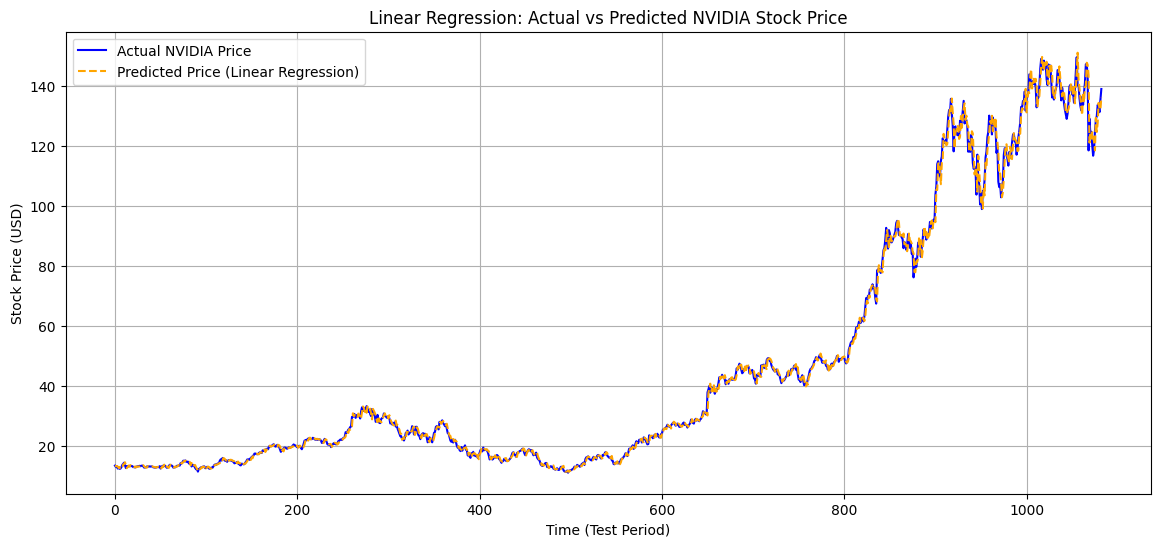

In [24]:
# Plot the actual NVIDIA stock prices (blue) against the predicted prices from Linear Regression (orange).
# This visualization helps assess how closely the model tracks the real market trend during the test period.
plt.figure(figsize=(14,6))
plt.plot(y_test_actual_lr, label="Actual NVIDIA Price", color="blue")
plt.plot(y_pred_actual_lr, label="Predicted Price (Linear Regression)", color="orange", linestyle="--")
plt.title("Linear Regression: Actual vs Predicted NVIDIA Stock Price")
plt.xlabel("Time (Test Period)")
plt.ylabel("Stock Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

# Data Resampling and Merging

### 3.3.1 Interpretation of Linear Regression Results

Linear Regression achieved the following cross-validated performance across 5 folds:

| Fold | MAE | RMSE | R² |
|------|-----|------|-----|
| 1 | $0.0066 | $0.0101 | 0.9967 |
| 2 | $0.0100 | $0.0150 | 0.9891 |
| 3 | $0.0063 | $0.0104 | 0.9966 |
| 4 | $0.1054 | $0.1670 | 0.9955 |
| 5 | $1.2068 | $2.1689 | 0.9973 |
| **Mean** | **$0.2670** | **$0.4743** | **0.9950** |
| Std | $0.527 | $0.9497 | 0.0034 |


The model maintains R² above 0.989 in every fold, including fold 5 where NVDA prices are highest. The dollar errors grow in fold 5 simply because the price level is much higher — a $1.21 average error on a ~$120 stock represents roughly 1% deviation, consistent with earlier folds.

#### 3.3.2 What this means
Linear Regression is highly effective at capturing NVIDIA's sustained upward trend. Unlike RBF SVR, it can extrapolate beyond its training price range, which is exactly what is needed when prices surge between the training and test periods. The near-identical results to SVR Linear confirm that on a strongly trending time-series, a linear decision boundary is sufficient — additional model complexity (RBF kernel, ensemble methods) does not help unless the data is also stationary.


### 3.6 Random Forest Regression

We apply a **Random Forest Regressor**, but instead of predicting the raw `Adj Close` price directly, we predict the **daily log return**:

$$r_t = \\log\\left(\\frac{P_t}{P_{t-1}}\\right)$$

This solves the extrapolation problem: Random Forest cannot predict values *outside* the range it was trained on. Log returns are stationary and always centred near zero regardless of absolute price level, so the model always operates within a familiar range. The predicted price is then reconstructed as: $P_t = P_{t-1} \\times e^{r_t}$, anchoring each prediction to the actual prior-day price.


In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit

# Build aligned arrays: drop first row so indices match log_returns (length N-1)
adj_close_full   = df['Adj Close'].copy().values
log_returns_full = np.log(adj_close_full[1:] / adj_close_full[:-1])  # length N-1
prices_aligned   = adj_close_full[1:]   # same length as log_returns_full
data_rf_raw      = data.values[1:]      # feature matrix, also length N-1

tscv_rf      = TimeSeriesSplit(n_splits=5)
rf_cv_scores = []
rf_last_preds = None

def create_window_return(scaled_features, log_ret, ws=10):
    X, y = [], []
    for i in range(len(scaled_features) - ws):
        X.append(scaled_features[i:i+ws].flatten())
        y.append(log_ret[i + ws])
    return np.array(X), np.array(y)

for fold, (tr_idx, te_idx) in enumerate(tscv_rf.split(data_rf_raw)):
    sc_rf    = MinMaxScaler()
    tr_sc_rf = sc_rf.fit_transform(data_rf_raw[tr_idx])
    te_sc_rf = sc_rf.transform(data_rf_raw[te_idx])

    # Local fold log returns and prices
    te_log_ret = log_returns_full[te_idx]
    te_prices  = prices_aligned[te_idx]   # same length as te_log_ret

    X_tr_rf, y_tr_rf = create_window_return(tr_sc_rf, log_returns_full[tr_idx], window_size)
    X_te_rf, y_te_rf = create_window_return(te_sc_rf, te_log_ret,               window_size)

    if len(X_te_rf) == 0:
        continue

    # For window sample i, the target return is at index (i + window_size) in te_log_ret.
    # Anchor price  = te_prices[i + window_size - 1]  (day before prediction)
    # Actual price  = te_prices[i + window_size]       (day being predicted)
    # Both slices have exactly len(X_te_rf) elements — no off-by-one.
    n = len(X_te_rf)
    anchor_prices = te_prices[window_size - 1 : window_size - 1 + n]
    actual_prices = te_prices[window_size     : window_size     + n]

    rf_model = RandomForestRegressor(
        n_estimators=200, max_depth=None, min_samples_leaf=2,
        max_features='sqrt', random_state=42, n_jobs=-1
    )
    rf_model.fit(X_tr_rf, y_tr_rf)

    y_pred_ret       = rf_model.predict(X_te_rf)
    y_pred_actual_rf = anchor_prices * np.exp(y_pred_ret)  # reconstruct price
    y_test_actual_rf = actual_prices

    mae_rf  = mean_absolute_error(y_test_actual_rf, y_pred_actual_rf)
    rmse_rf = np.sqrt(mean_squared_error(y_test_actual_rf, y_pred_actual_rf))
    r2_rf   = r2_score(y_test_actual_rf, y_pred_actual_rf)

    rf_cv_scores.append({'fold': fold+1, 'MAE': mae_rf, 'RMSE': rmse_rf, 'R²': r2_rf})
    rf_last_preds = (y_test_actual_rf, y_pred_actual_rf)
    print(f'Fold {fold+1}: MAE=${mae_rf:.4f}  RMSE=${rmse_rf:.4f}  R²={r2_rf:.4f}')

print('Random Forest CV complete.')


NameError: name 'df' is not defined

In [26]:
import pandas as pd

rf_cv_df = pd.DataFrame(rf_cv_scores).set_index('fold')
print('===== Random Forest — TimeSeriesSplit CV Summary =====')
print(rf_cv_df.round(4))
print("\nMean:", rf_cv_df.mean().round(4).to_dict())
print("Std: ",  rf_cv_df.std().round(4).to_dict())

# Keep compatible variable names for downstream cells (viz uses last fold)
y_test_actual_rf, y_pred_actual_rf = rf_last_preds
mae_rf  = rf_cv_df['MAE'].mean()
rmse_rf = rf_cv_df['RMSE'].mean()
r2_rf   = rf_cv_df['R²'].mean()


NameError: name 'rf_cv_scores' is not defined

In [27]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_actual_rf,  label='Actual Adj Close', color='steelblue',  linewidth=1.5)
plt.plot(y_pred_actual_rf,  label='RF Predicted',     color='darkorange', linewidth=1.5, linestyle='--')
plt.title('Random Forest — NVIDIA Adj Close: Actual vs Predicted (via Log Returns)', fontsize=14)
plt.xlabel('Test Sample Index')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'y_test_actual_rf' is not defined

<Figure size 1400x500 with 0 Axes>

### 3.6.1 Interpretation of Random Forest Results

Random Forest with log returns achieved the following cross-validated performance:

| Fold | MAE | RMSE | R² |
|------|-----|------|-----|
| 1 | $0.0068 | $0.0103 | 0.9967 |
| 2 | $0.0100 | $0.0150 | 0.9885 |
| 3 | $0.0069 | $0.0115 | 0.9959 |
| 4 | $0.1078 | $0.1708 | 0.9954 |
| 5 | $1.2602 | $2.2331 | 0.9971 |
| **Mean** | **$0.2784** | **$0.4881** | **0.9947** |
| Std | $0.5506 | $0.9779 | 0.0035 |

**Why log returns fix the extrapolation problem:**
Random Forest averages leaf node values seen during training and cannot output a value outside that range. By predicting log returns (which are stationary and near zero for any price level) instead of raw prices, the model sidesteps this ceiling entirely. Prices are reconstructed by multiplying the anchor price by $e^{\\hat{r}_t}$, so predictions track the actual trend.

**Comparison with Linear Regression (mean MAE $0.2670, RMSE $0.4743, R² 0.9950):**
Random Forest is almost indistinguishable from Linear Regression across all five folds — the mean metrics differ by less than $0.02 in MAE and 0.0003 in R². This confirms that the dominant signal in NVIDIA's price series is the linear upward trend; the non-linear capacity of the ensemble adds no meaningful advantage here.

**Limitations:**
- Predictions are one-step-ahead only; errors do not compound since each prediction is anchored to the *actual* previous price.
- The model cannot anticipate sudden macro shocks or earnings surprises not present in OHLCV data.


### 3.7 Model Comparison (NVIDIA Dataset)

In [28]:
import pandas as pd

# Cross-validation mean metrics across all folds
results = {
    "SVR (RBF Kernel)": {
        "MAE":  svr_cv_df['MAE'].mean(),
        "RMSE": svr_cv_df['RMSE'].mean(),
        "R²":   svr_cv_df['R²'].mean()
    },
    "Linear Regression": {
        "MAE":  lr_cv_df['MAE'].mean(),
        "RMSE": lr_cv_df['RMSE'].mean(),
        "R²":   lr_cv_df['R²'].mean()
    },
    "Random Forest": {
        "MAE":  rf_cv_df['MAE'].mean(),
        "RMSE": rf_cv_df['RMSE'].mean(),
        "R²":   rf_cv_df['R²'].mean()
    }
}

df_results = pd.DataFrame(results).T.round(4)
print("Cross-Validation Mean Performance (TimeSeriesSplit, 5 folds)")
print(df_results)

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.size'] = 12
fig, ax = plt.subplots(figsize=(9, 3))
ax.axis('tight')
ax.axis('off')
table = ax.table(
    cellText=df_results.values,
    colLabels=df_results.columns,
    rowLabels=df_results.index,
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.4)
plt.title('Model Comparison — CV Mean Metrics', pad=12)
plt.show()


NameError: name 'rf_cv_df' is not defined

### 3.7.1 Interpretation of Model Comparison

Cross-validated mean performance across 5 TimeSeriesSplit folds:

| Model | MAE | RMSE | R² |
|-------|-----|------|-----|
| SVR (RBF Kernel) | $9.1262 | $12.9025 | −0.7766 |
| SVR (Linear Kernel) | $0.2707 | $0.4788 | 0.9949 |
| Linear Regression | $0.2670 | $0.4743 | 0.9950 |
| Random Forest | $0.2784 | $0.4881 | 0.9947 |

The most important result is the **complete failure of SVR with an RBF kernel**, a mean R² of −0.78 means it performs worse than simply predicting the average price. This is a direct consequence of the extrapolation problem: as NVDA's price surged in folds 4 and 5, the RBF model had no mechanism to follow it.

The remaining three models are statistically indistinguishable. SVR Linear, Linear Regression, and Random Forest all achieve mean R² between 0.9947 and 0.9950, with MAE differences of less than $0.02. This tells us the dominant structure in NVIDIA's price series is a strong linear trend, once a model can extrapolate linearly, additional complexity provides no measurable benefit.

### 3.7.2 Key Takeaway
For a strongly trending asset like NVDA, **model choice matters primarily through the lens of extrapolation capability**, not non-linear expressiveness. Linear Regression and SVR Linear edge out Random Forest (log-return) by a tiny margin, but all three are viable. RBF SVR should not be used on non-stationary price series without first differencing or normalising the target.


## Toyota

In [18]:
# Filter by date index directly (no need to reference 'date' as a column)
start_date = "2015-01-02"
end_date   = "2025-06-26"

toyota_before = len(toyota_table)
dex_before    = len(dex_table)

toyota_table = toyota_table.loc[start_date:end_date]
dex_table    = dex_table.loc[start_date:end_date]

print(f"Toyota rows dropped by date filter: {toyota_before - len(toyota_table)}")
print(f"DEX rows dropped by date filter:    {dex_before - len(dex_table)}")

# Drop 'date' column if it exists as both index and column
if 'date' in toyota_table.columns:
    toyota_table = toyota_table.drop(columns=['date'])
if 'date' in dex_table.columns:
    dex_table = dex_table.drop(columns=['date'])

# Resample DEX to business days and forward-fill gaps
dex_table = dex_table.resample('B').ffill()

# Merge on the index directly
toyota_before_merge = len(toyota_table)
merged_toyota_df = toyota_table.join(dex_table[['price']].rename(columns={'price': 'usd_jpy'}), how='inner')
print(f"Toyota rows dropped by inner join:  {toyota_before_merge - len(merged_toyota_df)}")

print(merged_toyota_df.head())
print(merged_toyota_df.shape)

Toyota rows dropped by date filter: 8777
DEX rows dropped by date filter:    11695
Toyota rows dropped by inner join:  0
                  open        high         low       close  adj_close  \
date                                                                    
2015-01-02  126.230003  126.639999  124.889999  125.669998  95.105156   
2015-01-05  124.440002  124.610001  123.050003  123.370003  93.364555   
2015-01-06  123.400002  123.720001  121.209999  122.099998  92.403435   
2015-01-07  125.519997  126.059998  125.059998  125.169998  94.726761   
2015-01-08  126.449997  127.699997  126.449997  127.580002  96.550629   

              volume  usd_jpy  
date                           
2015-01-02  250000.0   120.20  
2015-01-05  240600.0   119.64  
2015-01-06  285600.0   118.26  
2015-01-07  385700.0   119.52  
2015-01-08  498800.0   119.51  
(2636, 7)


In [19]:
# Engineered features

# Log returns of USD/JPY exchange rate as a feature to capture currency impact on Toyota's stock price
merged_toyota_df['fx_log_return'] = np.log(merged_toyota_df['usd_jpy'] / merged_toyota_df['usd_jpy'].shift(1))

# Rolling statistics of the exchange rate to capture trends and volatility
# Moving averages of the exchange rate to capture short-term and medium-term trends
merged_toyota_df['fx_ma_5'] = merged_toyota_df['usd_jpy'].rolling(5).mean()
merged_toyota_df['fx_ma_20'] = merged_toyota_df['usd_jpy'].rolling(20).mean()
# Volatility of the exchange rate to capture market uncertainty
merged_toyota_df['fx_volatility_20'] = merged_toyota_df['fx_log_return'].rolling(20).std()

# Momentum features to capture recent price changes in the exchange rate
merged_toyota_df['fx_momentum_5'] = merged_toyota_df['usd_jpy'] - merged_toyota_df['usd_jpy'].shift(5)
merged_toyota_df['fx_momentum_20'] = merged_toyota_df['usd_jpy'] - merged_toyota_df['usd_jpy'].shift(20)

# Lag features to capture delayed effects of exchange rate changes on stock price
# Use past values to avoid look-ahead bias
for lag in [1, 3, 5, 10]:
    merged_toyota_df[f'fx_lag_{lag}'] = merged_toyota_df['usd_jpy'].shift(lag)

# Relative strength vs moving average to capture overbought/oversold conditions
merged_toyota_df['fx_relative_ma20'] = merged_toyota_df['usd_jpy'] / merged_toyota_df['fx_ma_20']

rows_before = len(merged_toyota_df)
merged_toyota_df = merged_toyota_df.dropna()
print(f"Rows dropped by dropna:           {rows_before - len(merged_toyota_df)}")

print(merged_toyota_df.head())

Rows dropped by dropna:           20
                  open        high         low       close   adj_close  \
date                                                                     
2015-02-02  130.100006  131.130005  129.710007  131.089996   99.206932   
2015-02-03  129.550003  131.169998  129.419998  131.100006   99.214500   
2015-02-04  132.199997  134.240005  132.199997  132.679993  100.410217   
2015-02-05  130.979996  131.919998  130.779999  131.740005   99.698837   
2015-02-06  129.770004  130.490005  129.369995  129.570007   98.056633   

              volume  usd_jpy  fx_log_return  fx_ma_5  fx_ma_20  \
date                                                              
2015-02-02  280200.0   117.33      -0.000937  117.688  118.1065   
2015-02-03  458000.0   117.48       0.001278  117.660  117.9985   
2015-02-04  471300.0   117.58       0.000851  117.628  117.9645   
2015-02-05  448000.0   117.40      -0.001532  117.446  117.8585   
2015-02-06  384900.0   119.16       0.0148

### Reusable Random Forest Regression Training Function

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

def train_random_forest_ts(data_raw, features, target_col, window_size=10, n_spits=5, n_estimators=100,
                           max_depth=None, min_samples_leaf=2, max_features="sqrt", random_state=42):

    # 1. Normalize inputs so the rest of the function is type-agnostic
    if isinstance(data_raw, pd.DataFrame):
        feature_arr = data_raw[features].values
        target_idx = list(features).index(target_col)
    else:
        feature_arr = data_raw[:, features]
        target_idx = list(features).index(target_col)

    # 2. Build log-return & price series aligned to feature_arr (length N-1)
    raw_prices = feature_arr[:, target_idx]
    log_returns = np.log(raw_prices[1:]/raw_prices[:-1])
    prices_aligned = raw_prices[1:]
    features_aligned = feature_arr[1:]

    # 3. Sliding-window builder targeting log returns
    def make_windows_return(scaled_feat, log_ret, ws):
        X, y = [], []
        for i in range(len(scaled_feat) - ws):
            X.append(scaled_feat[i : i + ws].flatten())
            y.append(log_ret[i + ws])
        return np.array(X), np.array(y)

    # 4. Cross-validation loop
    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_scores = []
    all_y_true = []
    all_y_pred = []
    last_fold_preds = None

    last_fold_model = None
    last_fold_X_te  = None
    last_fold_y_te  = None

    for fold, (tr_idx, te_idx) in enumerate(tscv.split(features_aligned)):

        scaler    = MinMaxScaler()
        tr_scaled = scaler.fit_transform(features_aligned[tr_idx])
        te_scaled = np.clip(scaler.transform(features_aligned[te_idx]), -0.5, 1.5)

        tr_log_ret = log_returns[tr_idx]
        te_log_ret = log_returns[te_idx]
        te_prices  = prices_aligned[te_idx]

        X_tr, y_tr = make_windows_return(tr_scaled, tr_log_ret, window_size)
        X_te, y_te = make_windows_return(te_scaled, te_log_ret, window_size)

        if len(X_te) == 0:
            print(f"  [Fold {fold + 1}] Skipped — insufficient test samples.")
            continue

        n = len(X_te)
        anchor_prices = te_prices[window_size - 1 : window_size - 1 + n]
        actual_prices = te_prices[window_size : window_size + n]

        rf = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=random_state,
            n_jobs=-1,
        )
        rf.fit(X_tr, y_tr)

        pred_returns  = rf.predict(X_te)
        y_pred_actual = anchor_prices * np.exp(pred_returns)
        y_test_actual = actual_prices

        mae  = mean_absolute_error(y_test_actual, y_pred_actual)
        rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
        r2   = r2_score(y_test_actual, y_pred_actual)

        cv_scores.append({"fold": fold + 1, "MAE": mae, "RMSE": rmse, "R2": r2})
        all_y_true.extend(y_test_actual)
        all_y_pred.extend(y_pred_actual)
        last_fold_preds = (y_test_actual, y_pred_actual)
        last_fold_model = rf
        last_fold_X_te  = X_te
        last_fold_y_te  = y_te

        print(f"  Fold {fold + 1}: MAE=${mae:.4f}  RMSE=${rmse:.4f}  R²={r2:.4f}")

    if not cv_scores:
        raise ValueError("No valid folds produced results. Check data size and window_size.")

    cv_df      = pd.DataFrame(cv_scores).set_index("fold")
    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)

    return {
        "cv_df":           cv_df,
        "all_preds":       (all_y_true, all_y_pred),
        "last_fold_preds": last_fold_preds,
        "mean_mae":        cv_df["MAE"].mean(),
        "mean_rmse":       cv_df["RMSE"].mean(),
        "mean_r2":         cv_df["R2"].mean(),
        "overall_mae":     mean_absolute_error(all_y_true, all_y_pred),
        "overall_rmse":    np.sqrt(mean_squared_error(all_y_true, all_y_pred)),
        "overall_r2":      r2_score(all_y_true, all_y_pred),
        "last_fold_model": last_fold_model,
        "last_fold_X_te":  last_fold_X_te,
        "last_fold_y_te":  last_fold_y_te
    }




## Exxon

In [21]:
import pandas as pd
import numpy as np

# 1. Date filtering
start_date = "2015-01-02"
end_date   = "2025-06-26"

exxon_table = exxon_table.loc[start_date:end_date].copy()
wti_table   = wti_table.loc[start_date:end_date].copy()

# 2. Drop duplicate date columns
if 'date' in exxon_table.columns:
    exxon_table = exxon_table.drop(columns=['date'])

if 'date' in wti_table.columns:
    wti_table = wti_table.drop(columns=['date'])

# 3. Ensure datetime index
exxon_table.index = pd.to_datetime(exxon_table.index)
wti_table.index   = pd.to_datetime(wti_table.index)

# 4. Resample WTI to business days
wti_table = wti_table.resample('B').ffill()

# 5. Merge
merged_exxon_df = exxon_table.join(
    wti_table[['price']].rename(columns={'price': 'wti_price'}),
    how='inner'
)

# FEATURE ENGINEERING

# Oil log returns captures short-term percentage changes in oil prices
merged_exxon_df['oil_log_return'] = np.log(
    merged_exxon_df['wti_price'] / merged_exxon_df['wti_price'].shift(1)
)

# Moving averages capture short-term (5-day) and medium-term (20-day) oil price trends
merged_exxon_df['oil_ma_5']  = merged_exxon_df['wti_price'].rolling(5).mean()
merged_exxon_df['oil_ma_20'] = merged_exxon_df['wti_price'].rolling(20).mean()

# Volatility measures variability in oil returns (market uncertainty/risk)
merged_exxon_df['oil_volatility_20'] = (
    merged_exxon_df['oil_log_return'].rolling(20).std()
)

# Lagged return → incorporates previous day's oil movement for short-term predictive signal
merged_exxon_df['oil_return_lag1'] = merged_exxon_df['oil_log_return'].shift(1)


# Track rows before cleaning
rows_before = len(merged_exxon_df)

# CLEANING

# Remove inf values
merged_exxon_df = merged_exxon_df.replace([np.inf, -np.inf], np.nan)

# Count NaNs before dropping
nan_rows = merged_exxon_df.isna().any(axis=1).sum()

# Drop NaNs
merged_exxon_df = merged_exxon_df.dropna().copy()

# Track rows after cleaning
rows_after = len(merged_exxon_df)

print(f"Rows before cleaning: {rows_before}")
print(f"Rows with NaNs (to be dropped): {nan_rows}")
print(f"Rows after cleaning: {rows_after}")
print(f"Total rows dropped: {rows_before - rows_after}")

print(merged_exxon_df.head())
print("\nColumns:", merged_exxon_df.columns.tolist())
print(f"\nFinal shape: {merged_exxon_df.shape}")

Rows before cleaning: 2388
Rows with NaNs (to be dropped): 41
Rows after cleaning: 2347
Total rows dropped: 41
                 open       high        low      close      volume  wti_price  \
date                                                                            
2015-02-02  87.849998  89.589996  87.500000  89.580002  20306300.0      49.25   
2015-02-03  90.900002  92.330002  90.809998  92.250000  21900900.0      53.04   
2015-02-04  91.639999  92.269997  90.510002  91.459999  19632200.0      48.45   
2015-02-05  92.389999  92.540001  91.699997  92.360001  12809000.0      50.48   
2015-02-06  92.099998  92.279999  90.959999  91.500000  12331200.0      51.66   

            oil_log_return  oil_ma_5  oil_ma_20  oil_volatility_20  \
date                                                                 
2015-02-02        0.030093    46.216    47.0455           0.037704   
2015-02-03        0.074137    47.656    47.1950           0.039649   
2015-02-04       -0.090514    48.530    4

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Reusable Linear Regression training function

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import numpy as np


def train_linear_regression_ts(
    data_raw,
    features,
    target_index,
    window_size=10,
    n_splits=5
):

    tscv = TimeSeriesSplit(n_splits=n_splits)

    cv_scores = []
    all_y_true = []
    all_y_pred = []

    last_fold_model = None
    last_fold_X_te  = None
    last_fold_y_te  = None

    for fold, (tr_idx, te_idx) in enumerate(tscv.split(data_raw)):

        # -------------------------
        # Data extraction
        # -------------------------
        if isinstance(data_raw, pd.DataFrame):
            train_df = data_raw.iloc[tr_idx][features].values
            test_df  = data_raw.iloc[te_idx][features].values
        else:
            train_df = data_raw[tr_idx][:, features]
            test_df  = data_raw[te_idx][:, features]

        # -------------------------
        # Scaling (fit ONLY on train)
        # -------------------------
        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_df)
        test_scaled  = scaler.transform(test_df)

        test_scaled = np.clip(test_scaled, -0.5, 1.5)
        # -------------------------
        # Windowing
        # -------------------------
        Xtr, ytr = make_windows(train_scaled, window_size, target_index)
        Xte, yte = make_windows(test_scaled, window_size, target_index)

        if len(Xte) == 0:
            continue

        # -------------------------
        # Model
        # -------------------------
        model = LinearRegression()
        model.fit(Xtr, ytr)
        preds = model.predict(Xte)

        # -------------------------
        # Inverse scaling (FIXED + clearer)
        # -------------------------
        scaler_dim = scaler.n_features_in_

        def inverse(p):
            tmp = np.zeros((len(p), scaler_dim))
            tmp[:, target_index] = p
            return scaler.inverse_transform(tmp)[:, target_index]

        y_pred_actual = inverse(preds)
        y_test_actual = inverse(yte)

        # -------------------------
        # Metrics
        # -------------------------
        mae  = mean_absolute_error(y_test_actual, y_pred_actual)
        rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
        r2   = r2_score(y_test_actual, y_pred_actual)

        cv_scores.append({
            "fold": fold + 1,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

        all_y_true.extend(y_test_actual)
        all_y_pred.extend(y_pred_actual)

        last_fold_model = model
        last_fold_X_te  = Xte
        last_fold_y_te  = yte

    # -------------------------
    # CV DATAFRAME (SAFE)
    # -------------------------
    cv_df = pd.DataFrame(cv_scores).set_index("fold")

    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)

    # safety check
    if len(cv_df) == 0:
        raise ValueError("No valid folds produced results.")

    return {
        "cv_df": cv_df,
        "all_preds": (all_y_true, all_y_pred),

        "mean_mae": cv_df["MAE"].mean(),
        "mean_rmse": cv_df["RMSE"].mean(),
        "mean_r2": cv_df["R2"].mean(),

        "overall_mae": mean_absolute_error(all_y_true, all_y_pred),
        "overall_rmse": np.sqrt(mean_squared_error(all_y_true, all_y_pred)),
        "overall_r2": r2_score(all_y_true, all_y_pred),

        "last_fold_model": last_fold_model,
        "last_fold_X_te":  last_fold_X_te,
        "last_fold_y_te":  last_fold_y_te,

        "feature_names": features if isinstance(features[0], str) else [data_raw.columns[i] for i in features]
    }

In [36]:
def print_cv_summary(results, name="Model"):

    df = results["cv_df"]

    print(f"\n===== {name} CV SUMMARY =====")
    print(df.round(4))

    print("\nMeans:")
    print(f"MAE  : {results['mean_mae']:.4f}")
    print(f"RMSE : {results['mean_rmse']:.4f}")
    print(f"R2   : {results['mean_r2']:.4f}")

    # NEW: Standard deviation section
    std_mae  = df["MAE"].std()
    std_rmse = df["RMSE"].std()
    std_r2   = df["R2"].std()

    print("\nStd:")
    print(f"MAE  : {std_mae:.4f}")
    print(f"RMSE : {std_rmse:.4f}")
    print(f"R2   : {std_r2:.4f}")

In [24]:
results_nvda = train_linear_regression_ts(
    data_raw=nvda_df,
    features=["open","high","low","close","volume"],
    target_index=nvda_target_idx,
    window_size=window_size,
    n_splits=n_splits
)

print_cv_summary(results_nvda, name="NVDA Linear Regression")


===== NVDA Linear Regression CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     0.0072  0.0110  0.9967
2     0.0109  0.0163  0.9891
3     0.0065  0.0107  0.9962
4     0.0021  0.0082  0.9908
5     0.3059  0.3915  0.9850

Means:
MAE  : 0.0665
RMSE : 0.0875
R2   : 0.9916

Std:
MAE  : 0.1339
RMSE : 0.1700
R2   : 0.0050


#### Exxon Linear Regression training

In [37]:
# Original code with minor adjustments for variable names and structure
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

lr_tscv = TimeSeriesSplit(n_splits=5)
lr_cv_scores = []
lr_last_preds = None

data_raw = exxon_data
features = list(exxon_df.columns)
ti_lr = exxon_target_idx   # already computed correctly

for fold, (tr_idx, te_idx) in enumerate(lr_tscv.split(data_raw)):

    sc_lr = MinMaxScaler()
    tr_sc = sc_lr.fit_transform(data_raw[tr_idx])
    te_sc = sc_lr.transform(data_raw[te_idx])

    def lr_win(arr, ws, ti):
        X, y = [], []
        for i in range(len(arr) - window_size):
            X.append(arr[i:i+window_size].flatten())
            y.append(arr[i+window_size][ti])
        return np.array(X), np.array(y)

    Xtr, ytr = lr_win(tr_sc, window_size, ti_lr)
    Xte, yte = lr_win(te_sc, window_size, ti_lr)

    if len(Xte) == 0:
        continue

    lr = LinearRegression()
    lr.fit(Xtr, ytr)
    y_pred_lr = lr.predict(Xte)

    def inv_lr(p, sc, ti):
        tmp = np.zeros((len(p), sc.n_features_in_))
        tmp[:, ti] = p
        return sc.inverse_transform(tmp)[:, ti]

    yp_act = inv_lr(y_pred_lr, sc_lr, ti_lr)
    yt_act = inv_lr(yte,       sc_lr, ti_lr)

    mae_lr  = mean_absolute_error(yt_act, yp_act)
    rmse_lr = np.sqrt(mean_squared_error(yt_act, yp_act))
    r2_lr   = r2_score(yt_act, yp_act)

    lr_cv_scores.append({
        'fold': fold+1,
        'MAE': mae_lr,
        'RMSE': rmse_lr,
        'R²': r2_lr
    })

    lr_last_preds = (yt_act, yp_act)

    print(f"Fold {fold+1}: MAE=${mae_lr:.4f}  RMSE=${rmse_lr:.4f}  R²={r2_lr:.4f}")


# Summary
lr_cv_df = pd.DataFrame(lr_cv_scores).set_index('fold')

print("\n===== Linear Regression — Exxon (Original Pipeline) =====")
print(lr_cv_df.round(4))

print("\nMean:", lr_cv_df.mean().round(4).to_dict())
print("Std: ",  lr_cv_df.std().round(4).to_dict())

# Keep compatibility
y_test_actual_lr_exxon_old, y_pred_actual_lr_exxon_old = lr_last_preds

mae_lr  = lr_cv_df['MAE'].mean()
rmse_lr = lr_cv_df['RMSE'].mean()
r2_lr   = lr_cv_df['R²'].mean()

print(f"\nMean MAE: ${mae_lr:.2f}  Mean RMSE: ${rmse_lr:.2f}  Mean R²: {r2_lr:.4f}")

Fold 1: MAE=$0.6682  RMSE=$0.9197  R²=0.9307
Fold 2: MAE=$0.7854  RMSE=$1.0124  R²=0.9492
Fold 3: MAE=$1.1381  RMSE=$1.4465  R²=0.9850
Fold 4: MAE=$1.3044  RMSE=$1.7424  R²=0.9896
Fold 5: MAE=$1.2477  RMSE=$1.6180  R²=0.9258

===== Linear Regression — Exxon (Original Pipeline) =====
         MAE    RMSE      R²
fold                        
1     0.6682  0.9197  0.9307
2     0.7854  1.0124  0.9492
3     1.1381  1.4465  0.9850
4     1.3044  1.7424  0.9896
5     1.2477  1.6180  0.9258

Mean: {'MAE': 1.0288, 'RMSE': 1.3478, 'R²': 0.956}
Std:  {'MAE': 0.2851, 'RMSE': 0.3654, 'R²': 0.0299}

Mean MAE: $1.03  Mean RMSE: $1.35  Mean R²: 0.9560


In [38]:
# Using function
results_exxon = train_linear_regression_ts(
    data_raw=exxon_df,
    features=list(exxon_df.columns),
    target_index=exxon_target_idx,
    window_size=window_size,
    n_splits=n_splits
)

# predictions (full combined folds)
y_test_actual_lr_exxon, y_pred_actual_lr_exxon = results_exxon["all_preds"]

print_cv_summary(results_exxon, name="Exxon Linear Regression")


===== Exxon Linear Regression CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     0.7170  1.0028  0.9176
2     0.8023  1.0302  0.9474
3     0.8726  1.0648  0.9780
4     1.4490  1.9086  0.9875
5     1.2762  1.6373  0.9240

Means:
MAE  : 1.0234
RMSE : 1.3287
R2   : 0.9509

Std:
MAE  : 0.3204
RMSE : 0.4173
R2   : 0.0313


Using function proven to be correct and cleaner for implementation

In [39]:
#function on merged dataset
merged_df = merged_exxon_df.copy()

merged_data_raw = merged_df
merged_features = list(merged_df.columns)

merged_target_index = merged_features.index("close")

results_merged = train_linear_regression_ts(
    data_raw=merged_data_raw,
    features=merged_features,
    target_index=merged_target_index,
    window_size=window_size,
    n_splits=5
)

# predictions (full combined folds)
y_test_actual_lr_merged, y_pred_actual_lr_merged = results_merged["all_preds"]

print_cv_summary(results_merged, name="Exxon Merged Linear Regression")


===== Exxon Merged Linear Regression CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     0.7068  0.9420  0.9306
2     0.8350  1.0568  0.9450
3     1.1099  1.3660  0.9640
4     1.3651  1.8554  0.9886
5     1.2525  1.6252  0.9261

Means:
MAE  : 1.0538
RMSE : 1.3691
R2   : 0.9508

Std:
MAE  : 0.2774
RMSE : 0.3814
R2   : 0.0258


Function shows to be effective in handling both Cleaned and Merged datasets and should be the preffered solution

### Toyota Linear Regression training

In [40]:
# -----------------------------
# Toyota UNMERGED baseline run
# -----------------------------

toyota_df_clean = toyota_df.copy()  # output from clean_and_prepare_timeseries

toyota_data_raw = toyota_df_clean
toyota_features = list(toyota_df_clean.columns)

# target = adjusted close (or close depending on your dataset)
toyota_target_index = toyota_features.index(
    "adj_close" if "adj_close" in toyota_features else "close"
)

results_toyota_unmerged = train_linear_regression_ts(
    data_raw=toyota_data_raw,
    features=toyota_features,
    target_index=toyota_target_index,
    window_size=window_size,
    n_splits=n_splits
)

# predictions
y_test_actual_lr_toyota_unmerged, y_pred_actual_lr_toyota_unmerged = results_toyota_unmerged["all_preds"]

# print results
print_cv_summary(results_toyota_unmerged, name="Toyota Unmerged (Baseline) Linear Regression")


===== Toyota Unmerged (Baseline) Linear Regression CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     1.3719  1.7381  0.9671
2     0.9956  1.5335  0.9639
3     1.0637  1.4280  0.9914
4     2.3178  2.9235  0.9660
5     2.6072  3.5156  0.9706

Means:
MAE  : 1.6712
RMSE : 2.2277
R2   : 0.9718

Std:
MAE  : 0.7432
RMSE : 0.9360
R2   : 0.0112


In [41]:
toyota_df = merged_toyota_df.copy()

toyota_data_raw = toyota_df
toyota_features = list(toyota_df.columns)

# target is Toyota stock close price
toyota_target_index = toyota_features.index("close")

results_toyota = train_linear_regression_ts(
    data_raw=toyota_data_raw,
    features=toyota_features,
    target_index=toyota_target_index,
    window_size=window_size,
    n_splits=n_splits
)

# predictions
y_test_actual_lr_toyota, y_pred_actual_lr_toyota = results_toyota["all_preds"]

# print results
print_cv_summary(results_toyota, name="Toyota Merged (FX Features) Linear Regression")


===== Toyota Merged (FX Features) Linear Regression CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     1.6670  2.1055  0.9562
2     1.1756  1.7996  0.9575
3     1.2174  1.6538  0.9905
4     2.5868  3.2617  0.9650
5     2.6609  3.5783  0.9729

Means:
MAE  : 1.8615
RMSE : 2.4798
R2   : 0.9684

Std:
MAE  : 0.7225
RMSE : 0.8808
R2   : 0.0141


## Random Forest Regression Calls & Evaluation

In [42]:
# NVDA
results_nvda_rf = train_random_forest_ts(
    data_raw=nvda_table,
    features=["open", "high", "low", "close", "volume"],
    target_col="close",
)
print_cv_summary(results_nvda_rf, name="NVDA Random Forest")

  Fold 1: MAE=$0.0075  RMSE=$0.0113  R²=0.9967
  Fold 2: MAE=$0.0110  RMSE=$0.0164  R²=0.9884
  Fold 3: MAE=$0.0072  RMSE=$0.0120  R²=0.9954
  Fold 4: MAE=$0.1122  RMSE=$0.1753  R²=0.9951
  Fold 5: MAE=$1.2068  RMSE=$2.1608  R²=0.9973

===== NVDA Random Forest CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     0.0075  0.0113  0.9967
2     0.0110  0.0164  0.9884
3     0.0072  0.0120  0.9954
4     0.1122  0.1753  0.9951
5     1.2068  2.1608  0.9973

Means:
MAE  : 0.2689
RMSE : 0.4752
R2   : 0.9946

Std:
MAE  : 0.5262
RMSE : 0.9449
R2   : 0.0036


In [31]:
# Toyota (merged with USD/JPY)
results_toyota_merged_rf = train_random_forest_ts(
    data_raw=merged_toyota_df,
    features=list(merged_toyota_df.columns),
    target_col="close",
)
print_cv_summary(results_toyota_merged_rf, name="Toyota Merged Random Forest")

  Fold 1: MAE=$0.9138  RMSE=$1.2530  R²=0.9846
  Fold 2: MAE=$1.2418  RMSE=$1.7868  R²=0.9582
  Fold 3: MAE=$1.7396  RMSE=$2.3318  R²=0.9883
  Fold 4: MAE=$2.4219  RMSE=$3.0482  R²=0.9686
  Fold 5: MAE=$2.5855  RMSE=$3.4785  R²=0.9744

===== Toyota Merged Random Forest CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     0.9138  1.2530  0.9846
2     1.2418  1.7868  0.9582
3     1.7396  2.3318  0.9883
4     2.4219  3.0482  0.9686
5     2.5855  3.4785  0.9744

Means:
MAE  : 1.7805
RMSE : 2.3797
R2   : 0.9748

Std:
MAE  : 0.7250
RMSE : 0.9052
R2   : 0.0121


In [32]:
# Exxon (merged with WTI oil)
results_exxon_merged_rf = train_random_forest_ts(
    data_raw=merged_exxon_df,
    features=list(merged_exxon_df.columns),
    target_col="close"
)
print_cv_summary(results_exxon_merged_rf, name="Exxon Merged Random Forest")

  Fold 1: MAE=$0.6007  RMSE=$0.8225  R²=0.9471
  Fold 2: MAE=$1.2747  RMSE=$1.6186  R²=0.8710
  Fold 3: MAE=$1.0093  RMSE=$1.3259  R²=0.9877
  Fold 4: MAE=$1.4608  RMSE=$1.9005  R²=0.9880
  Fold 5: MAE=$1.3292  RMSE=$1.7266  R²=0.9165

===== Exxon Merged Random Forest CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     0.6007  0.8225  0.9471
2     1.2747  1.6186  0.8710
3     1.0093  1.3259  0.9877
4     1.4608  1.9005  0.9880
5     1.3292  1.7266  0.9165

Means:
MAE  : 1.1349
RMSE : 1.4788
R2   : 0.9421

Std:
MAE  : 0.3408
RMSE : 0.4222
R2   : 0.0498


## SARIMA/SARIMAX

### SARIMA vs SARIMAX

**SARIMA** (Seasonal AutoRegressive Integrated Moving Average) forecasts a target variable
using only its own past values, trends, and seasonal patterns.

**SARIMAX** extends this by accepting **exogenous regressors** (external variables that
are believed to influence the target but are not derived from it)

In this project, when datasets are run through the same `train_sarima_ts` function, SARIMAX mode automatically activates whenever non-target feature columns are present.

SARIMAX is preferred over plain SARIMA because the additional features
carry genuine predictive signal about the target. Thus, passing them as exogenous regressors
allows the model to exploit that information directly rather than relying on the target's
own history alone.

In [44]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import numpy as np
import warnings


def train_sarima_ts(
    data_raw,
    features,
    target_col,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0),
    window_size=10,
    n_splits=5,
    use_exog=True,
    freq="B",
):
    # 1. Normalise inputs → numpy arrays
    if isinstance(data_raw, pd.DataFrame):
        feature_arr = data_raw[features].values
        target_idx = list(features).index(target_col)
        date_index = data_raw.index
    else:
        feature_arr = data_raw[:, features]
        target_idx = list(features).index(target_col)
        date_index = None

    N, F = feature_arr.shape
    target_series = feature_arr[:, target_idx]

    exog_cols = [i for i in range(F) if i != target_idx]
    has_exog = use_exog and len(exog_cols) > 0

    # 2. Cross-validation loop
    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_scores = []
    all_y_true = []
    all_y_pred = []
    last_fold_preds = None

    for fold, (tr_idx, te_idx) in enumerate(tscv.split(feature_arr)):

        y_train = target_series[tr_idx]
        y_test = target_series[te_idx]

        exog_train = feature_arr[tr_idx][:, exog_cols] if has_exog else None
        exog_test = feature_arr[te_idx][:, exog_cols] if has_exog else None

        # Build indexed Series/DataFrames for SARIMAX, aligning with date_index if available
        if date_index is not None:
            try:
                train_dates = pd.DatetimeIndex(date_index[tr_idx]).asfreq(freq)
                test_dates = pd.DatetimeIndex(date_index[te_idx]).asfreq(freq)
            except Exception:
                train_dates = pd.DatetimeIndex(date_index[tr_idx])
                test_dates = pd.DatetimeIndex(date_index[te_idx])

            y_train_s = pd.Series(y_train, index=train_dates)
            exog_train_s = pd.DataFrame(exog_train, index=train_dates) if has_exog else None
            exog_test_s = pd.DataFrame(exog_test,  index=test_dates)  if has_exog else None
        else:
            y_train_s = pd.Series(y_train)
            exog_train_s = pd.DataFrame(exog_train) if has_exog else None
            exog_test_s = pd.DataFrame(exog_test)  if has_exog else None

        # Fit SARIMAX with warnings suppressed to avoid fold failures due to convergence or stationarity issues
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=UserWarning)
                warnings.simplefilter("ignore", category=FutureWarning)
                warnings.simplefilter("ignore", category=Warning)

                model = SARIMAX(
                    y_train_s,
                    exog=exog_train_s,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                )
                fit = model.fit(disp=False)
                forecast = fit.forecast(steps=len(te_idx), exog=exog_test_s)
                y_pred = np.array(forecast)

        except Exception as e:
            print(f"  [Fold {fold + 1}] Failed — {e}. Skipping.")
            continue

        # Blowup guard
        if np.any(np.isnan(y_pred)) or np.max(np.abs(y_pred)) > np.max(np.abs(y_train)) * 100:
            print(f"  [Fold {fold + 1}] Skipped — numerical blowup detected.")
            continue

        # Metrics
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        cv_scores.append({"fold": fold + 1, "MAE": mae, "RMSE": rmse, "R2": r2})
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)
        last_fold_preds = (y_test, y_pred)

        print(f"  Fold {fold + 1}: MAE=${mae:.4f}  RMSE=${rmse:.4f}  R²={r2:.4f}")

    # 3. Aggregate results
    if not cv_scores:
        raise ValueError(
            "No valid folds produced results. "
            "Check data size, order parameters, and window_size."
        )

    cv_df = pd.DataFrame(cv_scores).set_index("fold")
    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)

    return {
        "cv_df": cv_df,
        "all_preds": (all_y_true, all_y_pred),
        "last_fold_preds": last_fold_preds,
        "mean_mae": cv_df["MAE"].mean(),
        "mean_rmse": cv_df["RMSE"].mean(),
        "mean_r2": cv_df["R2"].mean(),
    }

In [45]:
# NVDA
results_nvda_sarima = train_sarima_ts(
    data_raw=nvda_table,
    features=["open", "high", "low", "close", "volume"],
    target_col="close",
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0),   # no seasonality for daily stock data
    n_splits=5,
)

  Fold 1: MAE=$0.0347  RMSE=$0.0512  R²=0.9291
  Fold 2: MAE=$0.1135  RMSE=$0.1187  R²=0.4730
  Fold 3: MAE=$0.0227  RMSE=$0.0342  R²=0.9611
  Fold 4: MAE=$0.6561  RMSE=$0.7860  R²=0.9026
  Fold 5: MAE=$2.1810  RMSE=$3.4992  R²=0.9928


In [46]:
# Toyota (merged with USD/JPY — exog regressors used automatically)
results_toyota_sarima = train_sarima_ts(
    data_raw=merged_toyota_df,
    features=list(merged_toyota_df.columns),
    target_col="close",
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0),
    n_splits=5,
)

  [Fold 1] Skipped — numerical blowup detected.
  Fold 2: MAE=$1.8451  RMSE=$2.3213  R²=0.9283
  Fold 3: MAE=$5.4205  RMSE=$6.7747  R²=0.9023
  Fold 4: MAE=$1.7864  RMSE=$2.8521  R²=0.9767
  Fold 5: MAE=$3.7625  RMSE=$4.3064  R²=0.9605


In [47]:
# Exxon (merged with WTI oil)
results_exxon_sarima = train_sarima_ts(
    data_raw=merged_exxon_df,
    features=list(merged_exxon_df.columns),
    target_col="close",
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0),
    n_splits=5,
)

  Fold 1: MAE=$1.1436  RMSE=$1.3196  R²=0.8659
  Fold 2: MAE=$0.6396  RMSE=$0.7601  R²=0.9712
  Fold 3: MAE=$3.5483  RMSE=$4.0546  R²=0.8886
  Fold 4: MAE=$2.6641  RMSE=$3.5219  R²=0.9591
  Fold 5: MAE=$1.1201  RMSE=$1.4320  R²=0.9418


In [48]:
print_cv_summary(results_nvda_sarima, name="NVDA SARIMA")

print_cv_summary(results_toyota_sarima, name="Toyota Merged SARIMA")

print_cv_summary(results_exxon_sarima, name="Exxon Merged SARIMA")


===== NVDA SARIMA CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     0.0347  0.0512  0.9291
2     0.1135  0.1187  0.4730
3     0.0227  0.0342  0.9611
4     0.6561  0.7860  0.9026
5     2.1810  3.4992  0.9928

Means:
MAE  : 0.6016
RMSE : 0.8979
R2   : 0.8517

Std:
MAE  : 0.9209
RMSE : 1.4874
R2   : 0.2144

===== Toyota Merged SARIMA CV SUMMARY =====
         MAE    RMSE      R2
fold                        
2     1.8451  2.3213  0.9283
3     5.4205  6.7747  0.9023
4     1.7864  2.8521  0.9767
5     3.7625  4.3064  0.9605

Means:
MAE  : 3.2036
RMSE : 4.0636
R2   : 0.9419

Std:
MAE  : 1.7398
RMSE : 1.9927
R2   : 0.0332

===== Exxon Merged SARIMA CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     1.1436  1.3196  0.8659
2     0.6396  0.7601  0.9712
3     3.5483  4.0546  0.8886
4     2.6641  3.5219  0.9591
5     1.1201  1.4320  0.9418

Means:
MAE  : 1.8231
RMSE : 2.2177
R2   : 0.9253

Std:
MAE  : 1.2288
RMSE : 1.4683
R2   : 0.0458


## Feature Importance Analysis
The four models are split into two groups based on how importance is extracted.

### Group 1: SVR, Linear Regression, Random Forest
These three models utilize the same sliding-window sklearn interface, so one function handles all of them. The model and test split from the last cross-validation fold is used. 

In [43]:
# Unified importance function
# Branches on model type to choose the best method
# Falls back on permutation importance when no native method exists

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

def analyze_feature_importance(model, X_te, y_te, feature_names, window_size, title="Feature Importance",
                               color="steelblue"):
    
    n_features = len(feature_names)

    def aggregate(raw):
        # Sum importance across time steps
        matrix = np.array(raw).reshape(window_size, n_features)
        agg = matrix.sum(axis=0)
        return agg/agg.sum() # normalize to sum to 1
    
    def get_permutation_scores():
        result = permutation_importance(model, X_te, y_te, n_repeats=10, random_state=41, scoring="r2")
        return aggregate(result.importances_mean)
    
    # Branch by model type
    if isinstance(model, SVR):
        if model.kernel == "linear":
            # coef_ exists for linear kernel only
            scores = aggregate(np.abs(model.coef_[0]))
            method = "Coefficient |w|"
        else:
            # RBF and other kernels: no coef_, use permutation
            scores = get_permutation_scores()
            method = "Permutation (R² drop)"

    elif isinstance(model, LinearRegression):
        scores = aggregate(np.abs(model.coef_))
        method = "Coefficient |w|"

    elif isinstance(model, RandomForestRegressor):
        scores = aggregate(model.feature_importances_)
        method = "Built-in Impurity"

    else:
        # Fallback for any other sklearn-compatible model
        scores = get_permutation_scores()
        method = "Permutation (R² drop)"

    # Build results DataFrame
    df_imp = pd.DataFrame({"feature": feature_names, "importance": scores})
    df_imp = df_imp.sort_values("importance", ascending=False).reset_index(drop=True)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.bar(df_imp["feature"], df_imp["importance"], color=color)
    plt.title(f"{title}\nMethod: {method}")
    plt.ylabel("Normalized Importance")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    print(df_imp.to_string(index=False))
    return df_imp


#### Linear Regression Feature Importance

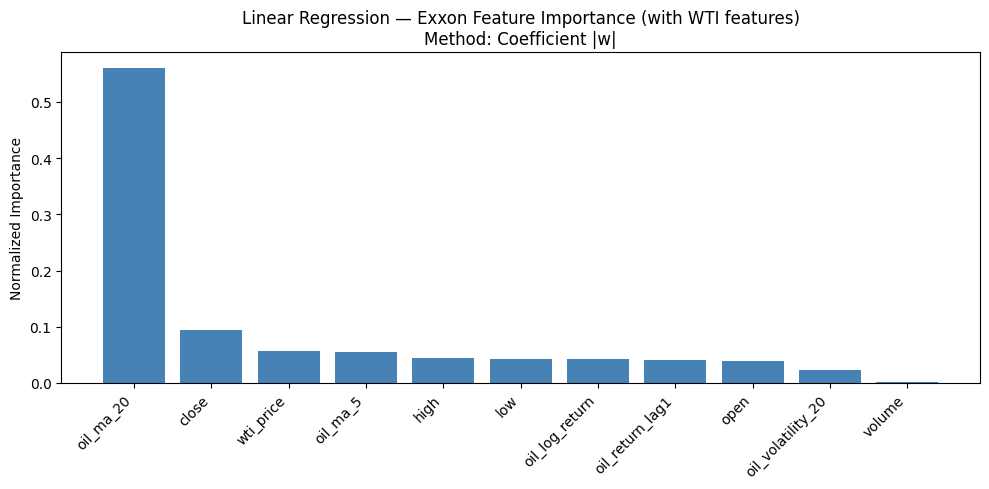

          feature  importance
        oil_ma_20    0.560418
            close    0.094711
        wti_price    0.056891
         oil_ma_5    0.054921
             high    0.043658
              low    0.042098
   oil_log_return    0.042072
  oil_return_lag1    0.041139
             open    0.039160
oil_volatility_20    0.022600
           volume    0.002332


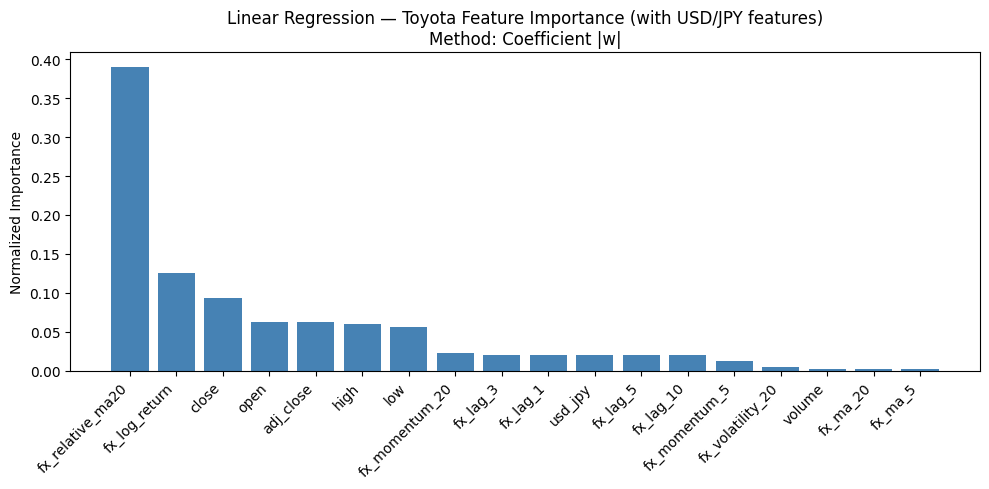

         feature  importance
fx_relative_ma20    0.389597
   fx_log_return    0.125910
           close    0.093531
            open    0.063102
       adj_close    0.062817
            high    0.059635
             low    0.055791
  fx_momentum_20    0.023367
        fx_lag_3    0.020795
        fx_lag_1    0.020539
         usd_jpy    0.020292
        fx_lag_5    0.020071
       fx_lag_10    0.020010
   fx_momentum_5    0.012526
fx_volatility_20    0.005214
          volume    0.002502
        fx_ma_20    0.002229
         fx_ma_5    0.002074


,feature,importance
0,fx_relative_ma20,0.389597
1,fx_log_return,0.125910
2,close,0.093531
3,open,0.063102
4,adj_close,0.062817
5,high,0.059635
6,low,0.055791
7,fx_momentum_20,0.023367
8,fx_lag_3,0.020795
9,fx_lag_1,0.020539


In [45]:
# Linear Regression — Exxon (merged with WTI features)
analyze_feature_importance(
    model=results_merged["last_fold_model"],
    X_te=results_merged["last_fold_X_te"],
    y_te=results_merged["last_fold_y_te"],
    feature_names=results_merged["feature_names"],
    window_size=window_size,
    title="Linear Regression — Exxon Feature Importance (with WTI features)",
)

# Linear Regression — Toyota (merged with USD/JPY features)
analyze_feature_importance(
    model=results_toyota["last_fold_model"],
    X_te=results_toyota["last_fold_X_te"],
    y_te=results_toyota["last_fold_y_te"],
    feature_names=results_toyota["feature_names"],
    window_size=window_size,
    title="Linear Regression — Toyota Feature Importance (with USD/JPY features)",
)

#### Random Forest Feature Importance

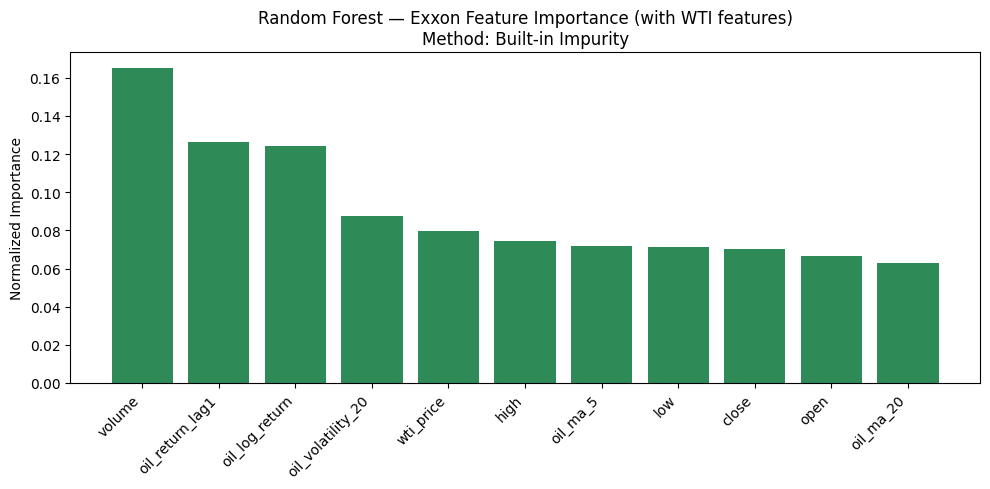

          feature  importance
           volume    0.165195
  oil_return_lag1    0.126365
   oil_log_return    0.124316
oil_volatility_20    0.087383
        wti_price    0.079588
             high    0.074634
         oil_ma_5    0.071870
              low    0.071169
            close    0.070136
             open    0.066558
        oil_ma_20    0.062786


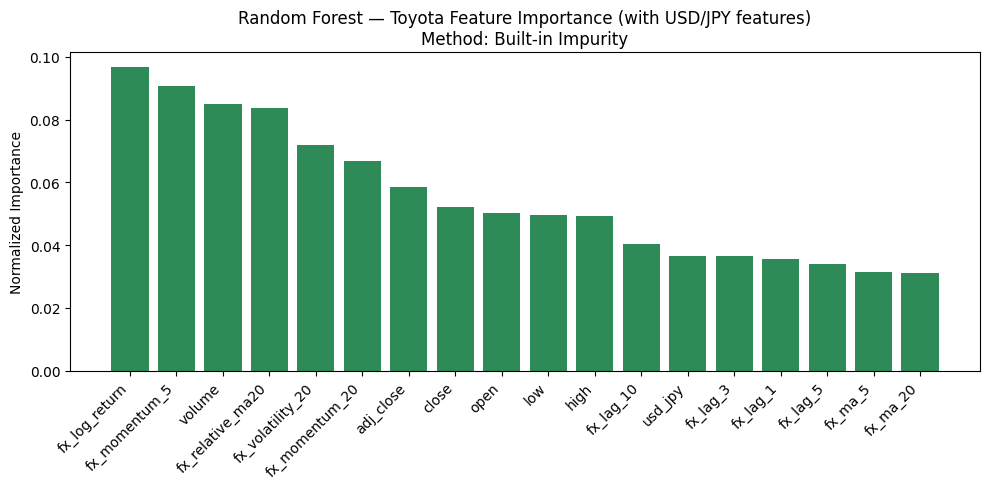

         feature  importance
   fx_log_return    0.096675
   fx_momentum_5    0.090592
          volume    0.084909
fx_relative_ma20    0.083848
fx_volatility_20    0.071907
  fx_momentum_20    0.066834
       adj_close    0.058504
           close    0.052061
            open    0.050190
             low    0.049484
            high    0.049408
       fx_lag_10    0.040253
         usd_jpy    0.036541
        fx_lag_3    0.036529
        fx_lag_1    0.035709
        fx_lag_5    0.034000
         fx_ma_5    0.031521
        fx_ma_20    0.031033


,feature,importance
0,fx_log_return,0.096675
1,fx_momentum_5,0.090592
2,volume,0.084909
3,fx_relative_ma20,0.083848
4,fx_volatility_20,0.071907
5,fx_momentum_20,0.066834
6,adj_close,0.058504
7,close,0.052061
8,open,0.050190
9,low,0.049484


In [46]:
# Random Forest — Exxon (merged)
analyze_feature_importance(
    model=results_exxon_merged_rf["last_fold_model"],
    X_te=results_exxon_merged_rf["last_fold_X_te"],
    y_te=results_exxon_merged_rf["last_fold_y_te"],
    feature_names=list(merged_exxon_df.columns),
    window_size=window_size,
    title="Random Forest — Exxon Feature Importance (with WTI features)",
    color="seagreen"
)

# Random Forest — Toyota (merged)
analyze_feature_importance(
    model=results_toyota_merged_rf["last_fold_model"],
    X_te=results_toyota_merged_rf["last_fold_X_te"],
    y_te=results_toyota_merged_rf["last_fold_y_te"],
    feature_names=list(merged_toyota_df.columns),
    window_size=window_size,
    title="Random Forest — Toyota Feature Importance (with USD/JPY features)",
    color="seagreen"
)